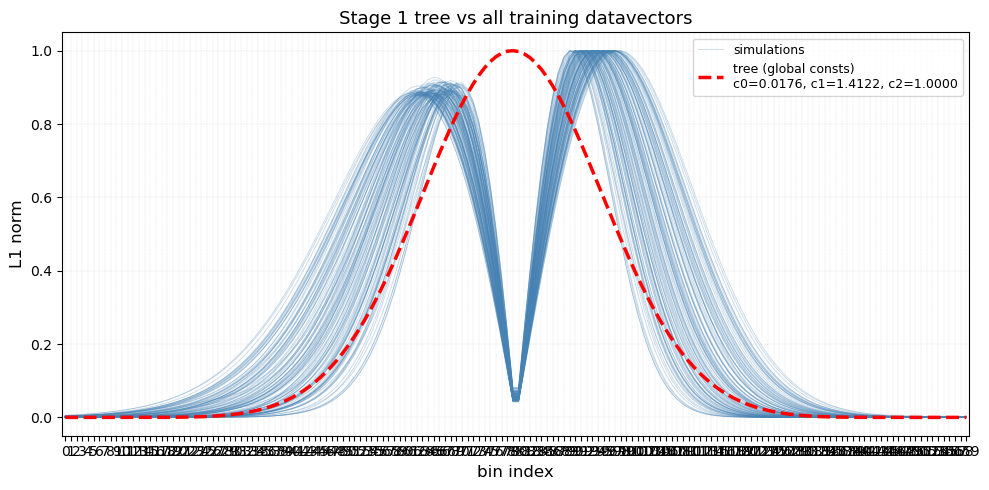

Saved: stage1_tree_overlay.png


In [6]:
"""
plot_stage1_tree.py  —  Visualise the Stage 1 tree vs actual datavectors
=========================================================================
Plots the tree f(bin_idx; c0, c1, c2) for bin_idx = 0..N_BINS-1
overlaid on the actual training datavectors.

Usage:
  python plot_stage1_tree.py
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

# ==============================================================================
# STAGE 1 TREE
# ==============================================================================
# Paste the tree found by SR here.
# Constants are the global values from SR — just for visual inspection.

def tree(bin_idx, c0, c1, c2):
    inner = (((((((((1.0+((((c1+bin_idx))**(2))/(c1+c1)))*c0)-bin_idx)+c1)*c0))**(2)))**(2))
    return (inner**2 + c0)**2

# Global constants from SR output (used only for the overlay line)
C0_GLOBAL =  0.01758431334075498
C1_GLOBAL =  1.4121895392222694
C2_GLOBAL = 1.0   # adjust these 3 values from your sr.log



N_BINS = 160

# ==============================================================================
# LOAD DATA
# ==============================================================================

with open('df_train.pkl', 'rb') as f:
    df_train = pickle.load(f)

n_sims   = len(df_train)
bin_axis = np.arange(N_BINS)

# Build matrix: (n_sims, N_BINS)
dv_matrix = np.stack(
    [df_train[f'bin_{j}'].to_numpy() for j in range(N_BINS)],
    axis=1
)

# ==============================================================================
# PLOT
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

# ── Actual datavectors ────────────────────────────────────────────────────────
for i in range(n_sims):
    ax.plot(bin_axis, (dv_matrix[i]-dv_matrix[i].min())/(dv_matrix[i].max()-dv_matrix[i].min()),
            color='steelblue', lw=0.6, alpha=0.3,
            label='simulations' if i == 0 else None)

# ── Tree with global constants ────────────────────────────────────────────────
y_tree = tree(bin_axis.astype(float), C0_GLOBAL, C1_GLOBAL, C2_GLOBAL)
ax.plot(bin_axis, (y_tree-y_tree.min())/(y_tree.max()-y_tree.min()),
        color='red', lw=2.5, ls='--', zorder=5,
        label=f'tree (global consts)\n'
              f'c0={C0_GLOBAL:.4f}, c1={C1_GLOBAL:.4f}, c2={C2_GLOBAL:.4f}')

ax.set_xlabel("bin index", fontsize=12)
ax.set_ylabel("L1 norm",   fontsize=12)
ax.set_title("Stage 1 tree vs all training datavectors", fontsize=13)
ax.set_xlim(-0.5, N_BINS - 0.5)
ax.set_xticks(bin_axis)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, lw=0.3, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig("stage1_tree_overlay.png", dpi=200)
plt.show()
print("Saved: stage1_tree_overlay.png")

usage: ipykernel_launcher.py [-h] [-nb N_BINS] [-s SEED]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/arnablahiry/Library/Jupyter/runtime/kernel-v3cfc232e862dbd283d13e1693403fddf864bcce90.json


SystemExit: 2

/Users/arnablahiry/miniforge3/envs/phi-so/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
